<a href="https://colab.research.google.com/github/anantc88/GenAI/blob/self/GenAI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   quantity   price  experience engineer  gender  location  budget_agency  \
0       499  261.52           5       No       0         7            839   
1       439  288.30           6       No       0        13           1410   
2       355  310.35           3      Yes       0        12           1043   
3       513  253.91           4       No       0        11            765   
4       413  307.83           6       No       0        14           1564   

   budget_phone  budget_social_media  
0           399                  440  
1           706                  704  
2           525                  518  
3           386                  379  
4           785                  779  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity             100 non-null    int64  
 1   price                100 non-null    float64


/tmp/ipython-input-21321437.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gender_label', data=df, palette='pastel', order=counts.index)


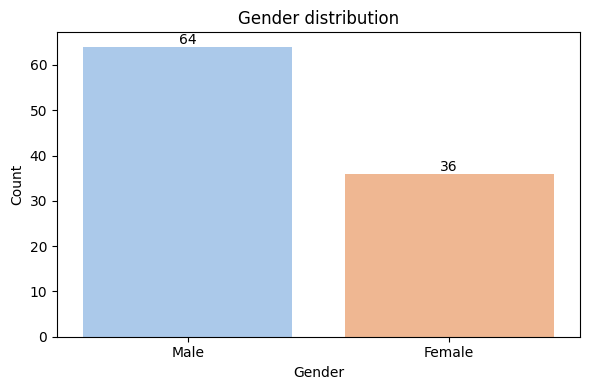

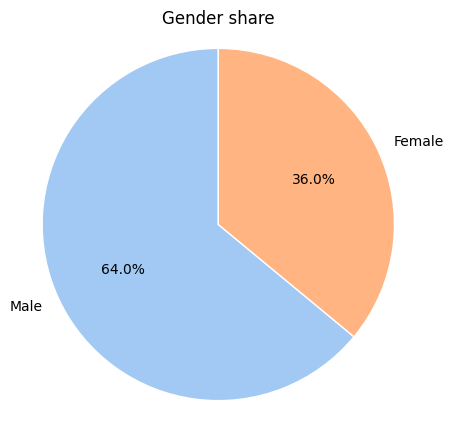

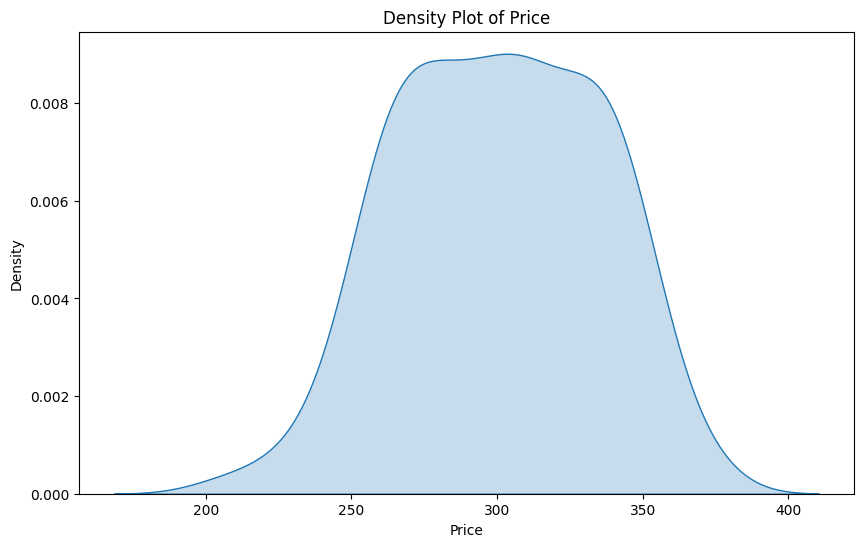

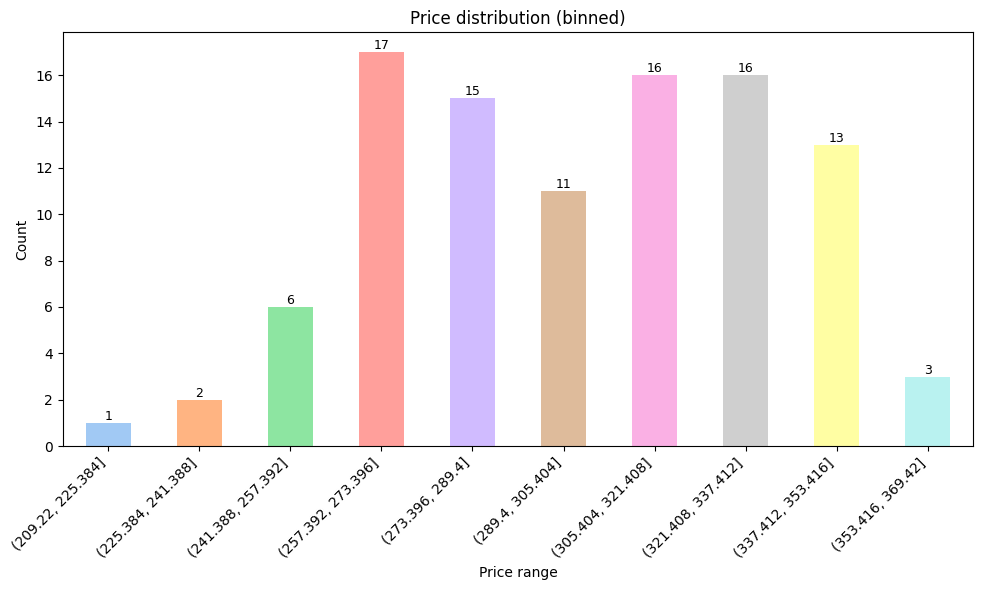

/tmp/ipython-input-21321437.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=exp_filled, order=exp_counts.index, palette='pastel')


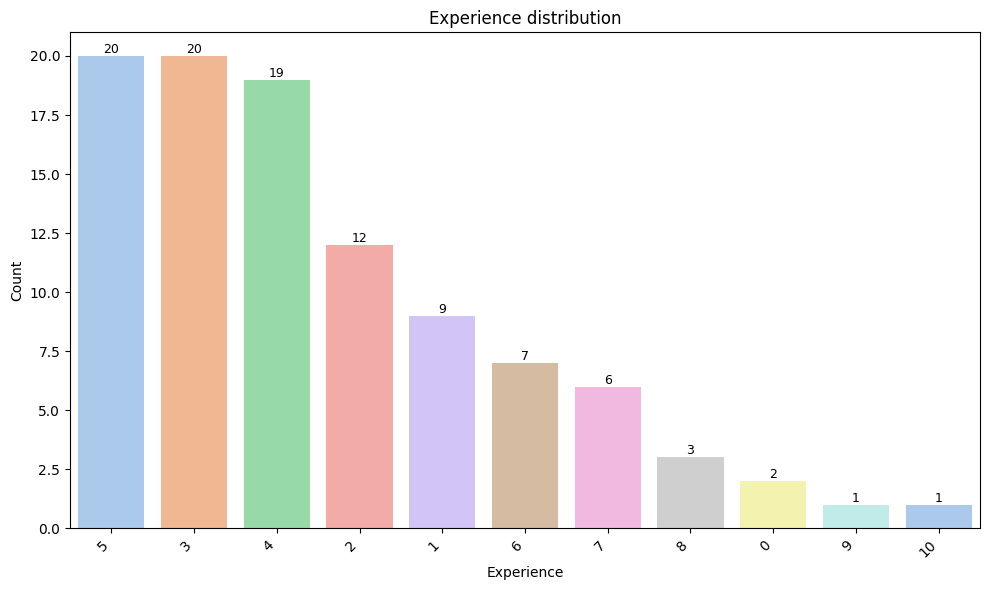

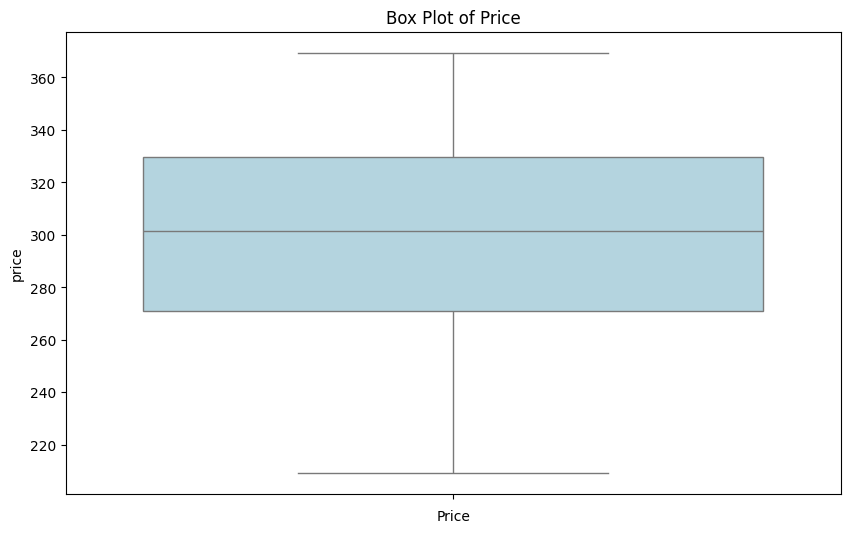

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Read Excel file "Sales_Data" from sheet "sheet1"
df = pd.read_excel("Sales_Data.xlsx", sheet_name="Sheet1")
df
# Quick inspection
print(df.head())
print(df.info())

#############
# Map numeric codes to labels and get counts
df['gender_label'] = df['gender'].map({0: 'Female', 1: 'Male'})
counts = df['gender_label'].value_counts(dropna=False)
print(counts)

# Count plot (bar)
plt.figure(figsize=(6,4))
ax = sns.countplot(x='gender_label', data=df, palette='pastel', order=counts.index)
ax.set_title('Gender distribution')
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Pie chart (percentages)
plt.figure(figsize=(5,5))
colors = sns.color_palette('pastel')[:len(counts)]
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops=dict(edgecolor='w'))
plt.title('Gender share')
plt.axis('equal')
plt.show()
##################################################
##### Density plot for price
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='price', fill=True)
plt.title('Density Plot of Price')
plt.xlabel('Price')
plt.ylabel('Density')
plt.show()

# Bar plot of price distribution (binned)
plt.figure(figsize=(10,6))
bins = 10  # adjust number of bins as needed
price_series = df['price'].dropna()
price_bins = pd.cut(price_series, bins=bins)
counts = price_bins.value_counts().sort_index()

ax = counts.plot(kind='bar', color=sns.color_palette('pastel', n_colors=bins))
ax.set_title('Price distribution (binned)')
ax.set_xlabel('Price range')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Bar plot for 'experience'
plt.figure(figsize=(10,6))
exp_series = df['experience']

# If numeric with many unique values, bin; otherwise treat as categorical (including missing)
if pd.api.types.is_numeric_dtype(exp_series) and exp_series.nunique(dropna=True) > 15:
    bins = 10
    exp_binned = pd.cut(exp_series.dropna(), bins=bins)
    exp_counts = exp_binned.value_counts().sort_index()
    ax = exp_counts.plot(kind='bar', color=sns.color_palette('pastel', n_colors=len(exp_counts)))
    ax.set_xlabel('Experience (binned)')
else:
    exp_filled = exp_series.fillna('Missing').astype(str)
    exp_counts = exp_filled.value_counts()
    ax = sns.countplot(x=exp_filled, order=exp_counts.index, palette='pastel')
    ax.set_xlabel('Experience')

ax.set_title('Experience distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate bars with counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Box plot for 'price'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['price'], color='lightblue')
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

In [4]:
from scipy.stats import ttest_ind

# Perform independent samples t-test
ttest_result = ttest_ind(df['budget_phone'], df['budget_social_media'])

# Display the results
print("Independent Samples t-test results:")
print(f"  Statistic: {ttest_result.statistic:.4f}")
print(f"  P-value: {ttest_result.pvalue:.4f}")

Independent Samples t-test results:
  Statistic: 0.0161
  P-value: 0.9872


In [5]:
import statsmodels.api as sm

# Define the independent variable (price) and the dependent variable (quantity)
X = df['price']
y = df['quantity']

# Add a constant to the independent variable for the intercept
X = sm.add_constant(X)

# Create and fit the OLS regression model
model = sm.OLS(y, X).fit()

# Print the regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               quantity   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     1789.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):           9.40e-65
Time:                        14:23:59   Log-Likelihood:                -458.45
No. Observations:                 100   AIC:                             920.9
Df Residuals:                      98   BIC:                             926.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1280.9487     21.247     60.288      0.0

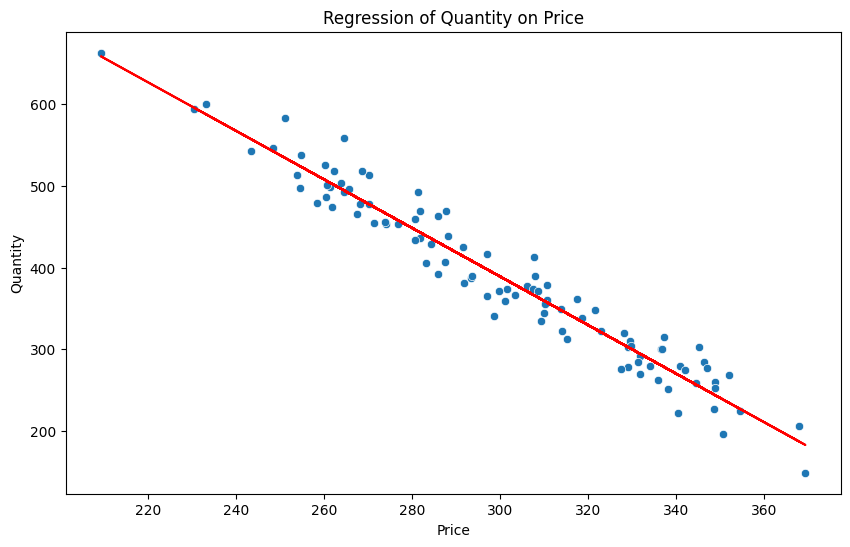

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of quantity vs price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['price'], y=df['quantity'])

# Add the regression line to the scatter plot
plt.plot(df['price'], model.predict(sm.add_constant(df['price'])), color='red')

plt.title('Regression of Quantity on Price')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.show()